**Emotion Recognition based on facial landmarks**

This part of the practical session is about **emotion recognition** based on facial landmarks. We will use the FEI dataset (https://fei.edu.br/~cet/facedatabase.html) to recognize the emotion of a person by analyzing 68 facial landmarks (already estimated and placed). Below, you will find a picture with an example. We will focus on two emotions neutral and happy.

Please answer all questions and complete the code where you see **XXXXXXXXXXXXX**

**Deadline**: Upload this notebook, the one about Toy Examples and the answers to the theoretical questions to E-Campus. Please verify the exact deadline on E-Campus.

First of all, we need to load the data. In Google Colab, we can load from Google Drive or from our local machine. Since it's faster from Google Drive, let's load them from (my) Google Drive, using the following code.

In [1]:
if 'google.colab' in str(get_ipython()):
  from google_drive_downloader import GoogleDriveDownloader as gdd
  gdd.download_file_from_google_drive(file_id='15vsAdMepHzdoZ3iqNS3kpI3KGW7D0vRs',
  dest_path='./Data_FEI.npz')
  gdd.download_file_from_google_drive(file_id='1ywQbf23-JoPklWCcH_mi5Nuw5BQskxvB',
  dest_path='./facial_landmarks_68markup.jpg')
else:
  print('You are not using Colab. Please define working_dir with the absolute path to the folder where you downloaded the data')

# Please modify working_dir only if you are using your Anaconda (and not Google Colab)
# You should write the absolute path of your working directory with the data
Working_directory="./"    

You are not using Colab. Please define working_dir with the absolute path to the folder where you downloaded the data


Otherwise, you can also load them from your local machine using the following code

In [3]:
"""
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))
"""      

'\nfrom google.colab import files\n\nuploaded = files.upload()\n\nfor fn in uploaded.keys():\n  print(\'User uploaded file "{name}" with length {length} bytes\'.format(\n      name=fn, length=len(uploaded[fn])))\n'

Let's load the Python packages containing the functions needed for the practical session.

In [2]:
import numpy as np
from time import time

import itertools
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import paired_distances
from sklearn.model_selection import  cross_val_score, cross_validate, GridSearchCV, KFold, StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.utils.multiclass import unique_labels
from sklearn.metrics import confusion_matrix
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn import decomposition
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt
# this is needed to plot figures within the notebook
%matplotlib inline 
np.random.seed(seed=666)

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings(action='ignore', category=ConvergenceWarning)

from sklearn.pipeline import make_pipeline

We also load a user-defined function useful for plotting the confusion matrix

In [3]:
# Code from scikit-learn

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    fig, ax = plt.subplots()
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.figure.colorbar(im, ax=ax)
    
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]), 
           xticklabels=classes, yticklabels=classes,
           title=title,
           ylabel='True label',
           xlabel='Predicted label')
    
    # Rotate the tick labels and set their alignment.
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
            rotation_mode="anchor")
  

    # Loop over data dimensions and create text annotations.
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], fmt),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    fig.tight_layout()
    return ax

Now, let's load the data. 

We have a list of images, the position of the original landmarks (aligned to the images), the position of the landmarks after a normalization process called Generalized Procrustes Analysis (please refer to https://en.wikipedia.org/wiki/Generalized_Procrustes_analysis), the outputs with the class labels and the names of the images.

Generalized Procrustes Analysis (GPA) is used to keep only shape differences between the configurations of landmarks. That is to say, we align all configurations to an average one using only rigid transformations (uniform scaling, rotation and translation). This means that if I take a facial picture of subject A, then step back, translate and rotate a bit the camera and retake a facial picture of the same subject (who has not moved) the two picture will be different with therefore different landmark position. However, after a GPA, the two landmark configurations should be perfectly aligned removing the "nuisance" differences related to rotation, translation and uniform scaling.

In [4]:
# Parameters
dim=2 # dimension   
# Loading data
with np.load(Working_directory + 'Data_FEI.npz') as data:
    Images=data['Images_FEI'] # list of images
    X = data['Landmarks_FEI'] # original landmarks   
    XGPA = data['Landmarks_FEI_GPA'] # landmarks after GPA (Generalized Procrustes Analysis, https://en.wikipedia.org/wiki/Generalized_Procrustes_analysis)
    Y = data['Emotions_FEI'] # class, 0 for neutral and 1 for happy
    Names = data['Names_FEI']    
N,M = X.shape # number subjects 
M = int(M/2) # Number of landmarks (they are in 2D)
print('Number of subjects:', N, '; Number of landmarks:',M) 
class_names = ["neutral","happy"]

Number of subjects: 400 ; Number of landmarks: 68


Here, we show an example of facial landmarks

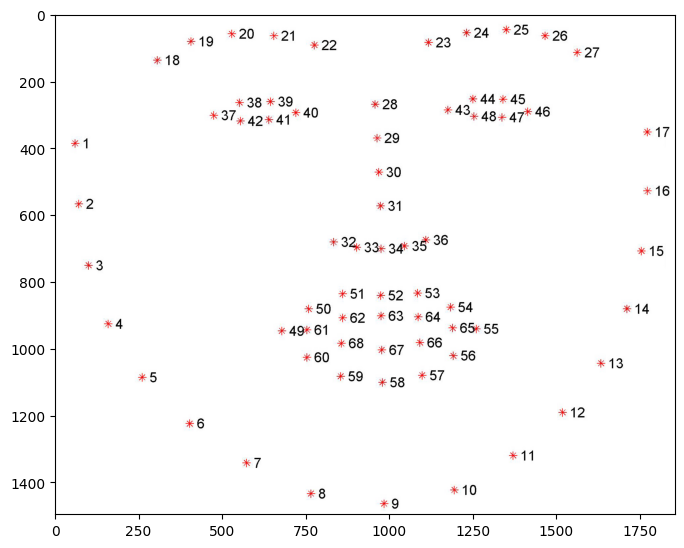

In [5]:
# Plot the facial landmarks
Example=plt.imread(Working_directory + './facial_landmarks_68markup.jpg') # function to read a jpg image
plt.figure(figsize = (8,8)) # Size of the plot
plt.imshow(Example)
plt.show()

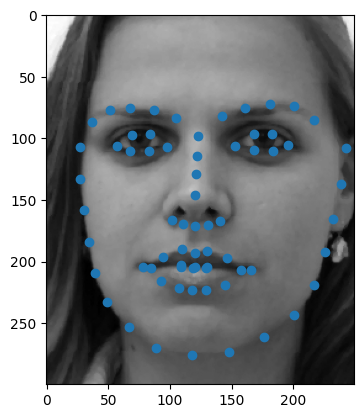

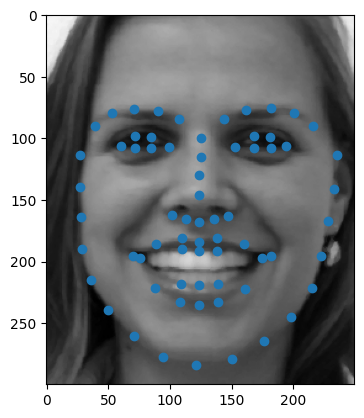

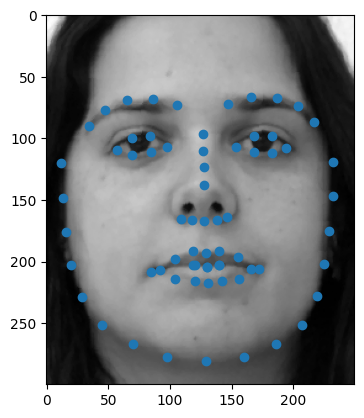

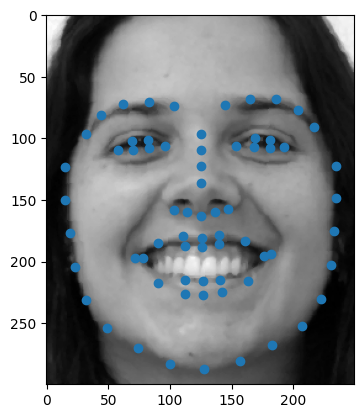

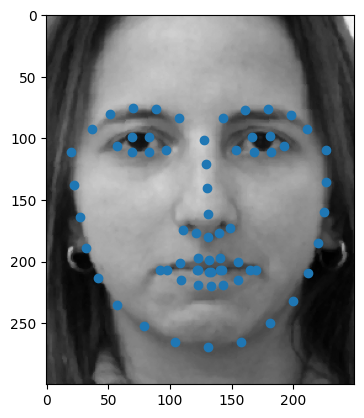

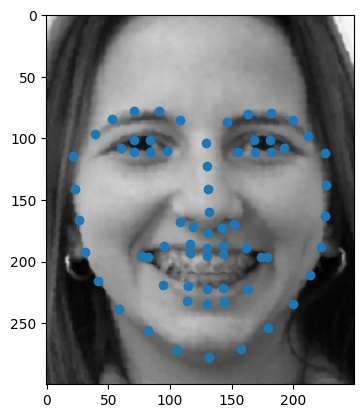

In [6]:
# plot the first 6 images of the data-set
for i in range(0,6):
    image = Images[i,:,:]
    plt.figure()
    plt.imshow(image, cmap='gray', origin='upper')
    landmark=X[i,:]
    x=landmark[::2]
    y=landmark[1::2]
    plt.plot(x,y,'o')
    plt.show()



---



**Question**: after plotting the first 6 images of the data-set, what do you notice ? Do you notice a regular pattern ? Do you think that it would be worth it to randomly shuffle the data ?




---

We see that the data-set is a collection of images in two variants : emotion-less and smiling.
so the dataset is grouped by people. For each people, we have two images of those two variants.
$i=1$ : women 1 emotion-less, $i=2$ : women 1 smiling, $i=3$ : women 2 emotion-less, $i=4$ : women 2 smiling, ...

It would be worth to shuffle the data in order not to bias our machine learning algorithms. 

In [7]:
# Shuffle data randomly. Hint: Use np.random.shuffle
"""There is a problem in the hint, we can't use np.random.shuffle since it doesn't return anything.
So I chose np.random.randint() function"""
indeces=np.random.randint(0, len(Images), len(Images))

XpGPA=XGPA[indeces]
Xp=X[indeces]
Yp=Y[indeces]
Imagesp=Images[indeces]
Xmean = np.mean(XpGPA,axis=0) # Compute average

Namesp=[''] * N
for i in range(0,N):
    Namesp[i]=Names[indeces[i]]   



---



Among the loaded data, we also have aligned landmarks after a Generalized Procrustes Analysis. Let's check them and compare them with the landmarks before alignement.


**QUESTION**: Please comment the results. What can you notice ?




---

We see that the landmarks are closer to the average ones AFTER GPA than before GPA. (Less variance around the average landmarks)

Text(0.5, 1.0, 'Landmarks BEFORE alignement (GPA)')

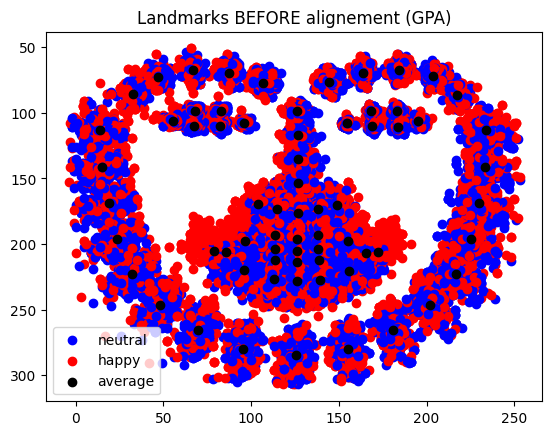

In [8]:
# Plot all landmarks BEFORE GPA
plt.figure()
for i in range(0,N):
    landmark=Xp[i]
    x=landmark[::2]
    y=landmark[1::2]
    if Yp[i].astype(int)==0:
        neutral=plt.scatter(x, y, c='b')
    else:
        happy=plt.scatter(x, y, c='r')
Xaverage = np.mean(Xp,axis=0) # Compute average
average=plt.scatter(Xaverage[::2],Xaverage[1::2],color='k')            
plt.legend((neutral,happy,average),('neutral','happy','average'))
plt.gca().invert_yaxis() 
plt.title('Landmarks BEFORE alignement (GPA)')

Text(0.5, 1.0, 'Landmarks AFTER alignement (GPA)')

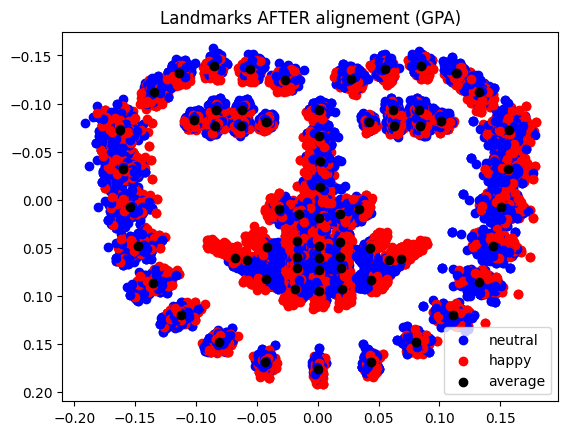

In [9]:
# Plot all landmarks AFTER GPA
plt.figure()
for i in range(0,N):
    landmark=XpGPA[i]
    x=landmark[::2]
    y=landmark[1::2]
    if Yp[i].astype(int)==0:
        neutral=plt.scatter(x, y, c='b')
    else:
        happy=plt.scatter(x, y, c='r')
average=plt.scatter(Xmean[::2],Xmean[1::2],color='k')            
plt.legend((neutral,happy,average),('neutral','happy','average'))
plt.gca().invert_yaxis()   
plt.title('Landmarks AFTER alignement (GPA)')



---


We need now to compute some features for the classification algorithms. As first idea, we could use the paired Euclidean distances between the landmarks of every subject and the landmarks of the average configuration. 



---



In [14]:
# Compute distances from the average configuration (features)
dist_average=np.zeros((N,M))
average=np.reshape(Xmean,(M,2)) # Reshape average as matrix
for i in range(N):
    landmark=XpGPA[i].reshape((M,2)) # Reshape all landmarks as matrices
    dist_average[i]=np.linalg.norm(landmark-average)  

print('Number of subjects N is: ', dist_average.shape[0], ' ; number of features is: ',  dist_average.shape[1] )


Number of subjects N is:  400  ; number of features is:  68


Let's divide the data-set into Training and Test sets:

In [15]:
# Create training and test set
X_train, X_test, y_train, y_test = train_test_split(dist_average, np.ravel(Yp), test_size=0.33, random_state=42)

---

**Question**: One usual question in Machine Learning is, do we need to scale/normalize the features ? What do you think ? Should we do it in this case ? Compute both scaled and normalized data.

Please note that we compute the parameters of 'StandardScaler()' and 'MinMaxScaler()' using only the training set and then we trasform both the traning and test sets using the parameters learnt only on the training set.

**Question**: Why do we do that in your opinion ?

---
- For Machine learning, we usually scale/normalize our datasets. When it is not scaled, some features can take big values compared to others, which can bias our machine learning algorithm (the gradients will be too high). In order to avoid it, we normalize it so that it gives the same importance to every feature.  \
    In our case, it is essential to do it, in order to avoid the machine learning algorithms to be biased by  the scale of the features.

- The test set represents unseen data, so the scaling parameters (mean and standard deviation for StandardScaler, min and max for MinMaxScaler) should be computed only on the training set to avoid biasing the evaluation of the model's performance on unseen data.

In [ ]:
# Scale data (each feature will have average equal to 0 and unit variance)
# https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scale=scaler.transform(X_train)
X_test_scale=scaler.transform(X_test)

# Normalize data (each feature will be scaled into the range 0,1)
# https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html?highlight=minmaxscaler#sklearn.preprocessing.MinMaxScaler

normalizer = MinMaxScaler()
normalizer.fit(X_train)
X_train_normalize=normalizer.transform(X_train)
X_test_normalize=normalizer.transform(X_test)




---



Let's try to fit LDA to all training sets and predict the error on their respective test sets. 

**Question**: Compare the performnces between original, scaled and normalized data. Comment the results.



---

We get the same results, that is because LDA is invariant to linear transformations of the feature. So the classifications will be the same.

Fitting LDA to training set
done in 0.005s
              precision    recall  f1-score   support

           0       0.56      0.78      0.66        74
           1       0.45      0.22      0.30        58

    accuracy                           0.54       132
   macro avg       0.51      0.50      0.48       132
weighted avg       0.51      0.54      0.50       132

Normalized confusion matrix
[[0.78378378 0.21621622]
 [0.77586207 0.22413793]]


<Figure size 640x480 with 0 Axes>

Fitting LDA to training set
done in 0.005s
              precision    recall  f1-score   support

           0       0.56      0.78      0.66        74
           1       0.45      0.22      0.30        58

    accuracy                           0.54       132
   macro avg       0.51      0.50      0.48       132
weighted avg       0.51      0.54      0.50       132

Normalized confusion matrix
[[0.78378378 0.21621622]
 [0.77586207 0.22413793]]


<Figure size 640x480 with 0 Axes>

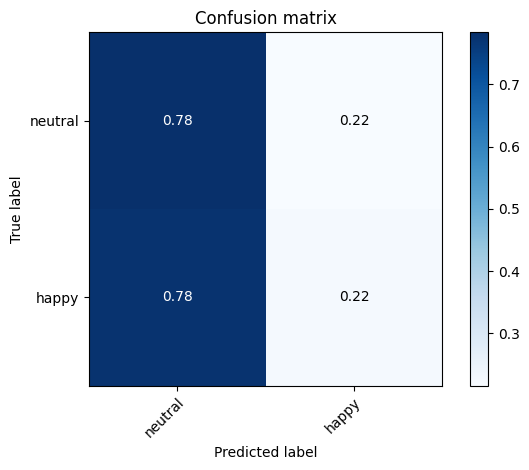

In [30]:
# Fitting LDA to original data
print("Fitting LDA to training set")
t0 = time()
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
y_pred_original = lda.predict(X_test)
print("done in %0.3fs" % (time() - t0))
print(classification_report(y_test, y_pred_original))

# Compute confusion matrix
cnf_matrix = confusion_matrix(y_test, y_pred_original)

# Plot normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=class_names, normalize=True)
plt.show()

Fitting LDA to scaled training set
done in 0.007s
              precision    recall  f1-score   support

           0       0.56      0.78      0.66        74
           1       0.45      0.22      0.30        58

    accuracy                           0.54       132
   macro avg       0.51      0.50      0.48       132
weighted avg       0.51      0.54      0.50       132

Normalized confusion matrix
[[0.78378378 0.21621622]
 [0.77586207 0.22413793]]


<Figure size 640x480 with 0 Axes>

Fitting LDA to scaled training set
done in 0.007s
              precision    recall  f1-score   support

           0       0.56      0.78      0.66        74
           1       0.45      0.22      0.30        58

    accuracy                           0.54       132
   macro avg       0.51      0.50      0.48       132
weighted avg       0.51      0.54      0.50       132

Normalized confusion matrix
[[0.78378378 0.21621622]
 [0.77586207 0.22413793]]


<Figure size 640x480 with 0 Axes>

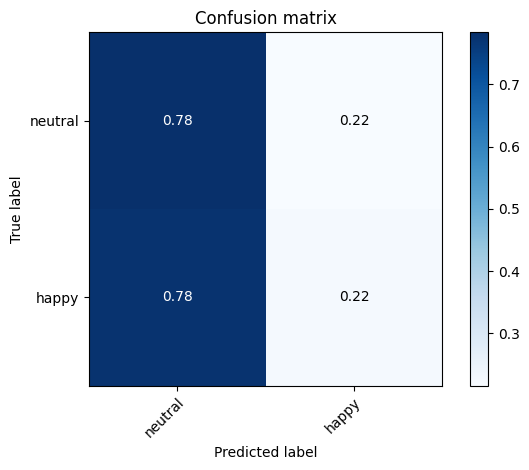

In [31]:
# Fitting LDA to scaled data
print("Fitting LDA to scaled training set")
t0 = time()
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_scale, y_train)
y_pred_scaled = lda.predict(X_test_scale)
print("done in %0.3fs" % (time() - t0))
print(classification_report(y_test, y_pred_scaled))

# Compute confusion matrix
cnf_matrix = confusion_matrix(y_test, y_pred_scaled)

# Plot normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=class_names, normalize=True)
plt.show()

Fitting LDA to normalized training set
done in 0.046s
              precision    recall  f1-score   support

           0       0.56      0.78      0.66        74
           1       0.45      0.22      0.30        58

    accuracy                           0.54       132
   macro avg       0.51      0.50      0.48       132
weighted avg       0.51      0.54      0.50       132

Normalized confusion matrix
[[0.78378378 0.21621622]
 [0.77586207 0.22413793]]


<Figure size 640x480 with 0 Axes>

Fitting LDA to normalized training set
done in 0.046s
              precision    recall  f1-score   support

           0       0.56      0.78      0.66        74
           1       0.45      0.22      0.30        58

    accuracy                           0.54       132
   macro avg       0.51      0.50      0.48       132
weighted avg       0.51      0.54      0.50       132

Normalized confusion matrix
[[0.78378378 0.21621622]
 [0.77586207 0.22413793]]


<Figure size 640x480 with 0 Axes>

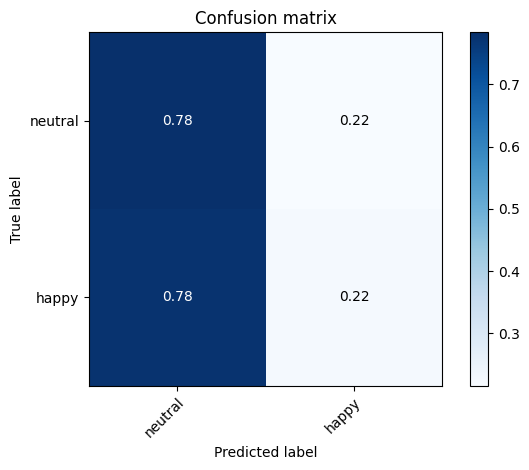

In [32]:
# Fitting LDA to normalized data
print("Fitting LDA to normalized training set")
t0 = time()
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_normalize, y_train)
y_pred_normalized = lda.predict(X_test_normalize)
print("done in %0.3fs" % (time() - t0))
print(classification_report(y_test, y_pred_normalized))

# Compute confusion matrix
cnf_matrix = confusion_matrix(y_test, y_pred_normalized)

# Plot normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=class_names, normalize=True)
plt.show()



---

We can then use the function 'cross_val_score' to compute the CV score. Let's use all methods seen today. 

---






In [34]:
# Cross-validation for Model Assessment

# Fitting LDA
print("Fitting LDA")
t0 = time()
lda = LinearDiscriminantAnalysis()
lda_score = cross_val_score(lda,X=dist_average, y=np.ravel(Yp),cv=5)
print("done in %0.3fs" % (time() - t0))
print(" Average and std CV score : {0} +- {1}".format(lda_score.mean(), lda_score.std() ))

# Fitting QDA
print("Fitting QDA")
t0 = time()
qda = QuadraticDiscriminantAnalysis()
qda_score = cross_val_score(qda, X=dist_average, y=np.ravel(Yp),cv=5)
print("done in %0.3fs" % (time() - t0))
print(" Average and std CV score : {0} +- {1}".format(qda_score.mean(), qda_score.std() ))

# Fitting Logistic-regression
print("Fitting Logistic Regression")
t0 = time()
logit = LogisticRegression(solver='lbfgs')
logit_score = cross_val_score(logit, X=dist_average, y=np.ravel(Yp),cv=5)
print("done in %0.3fs" % (time() - t0))
print(" Average and std CV score : {0} +- {1}".format(logit_score.mean(), logit_score.std() ))

# Fitting Naive-Bayes
print("Fitting Naive-Bayes")
t0 = time()
GNB = GaussianNB()
GNB_score = cross_val_score(GNB, X=dist_average, y=np.ravel(Yp),cv=5)
print("done in %0.3fs" % (time() - t0))
print(" Average and std CV score : {0} +- {1}".format(GNB_score.mean(), GNB_score.std() ))

# Fitting K-nearest neighbour
print("Fitting K-nearest neighbour")
t0 = time()
neigh = KNeighborsClassifier(n_neighbors=3)
neigh_score = cross_val_score(neigh, X=dist_average, y=np.ravel(Yp),cv=5)
print("done in %0.3fs" % (time() - t0))
print(" Average and std CV score : {0} +- {1}".format(neigh_score.mean(), neigh_score.std() ))

Fitting LDA
done in 0.178s
 Average and std CV score : 0.5174999999999998 +- 0.021794494717703387
Fitting QDA


Fitting LDA
done in 0.178s
 Average and std CV score : 0.5174999999999998 +- 0.021794494717703387
Fitting QDA


/home/mkhales-24/.local/lib/python3.10/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/home/mkhales-24/.local/lib/python3.10/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/home/mkhales-24/.local/lib/python3.10/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/home/mkhales-24/.local/lib/python3.10/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing

Fitting LDA
done in 0.178s
 Average and std CV score : 0.5174999999999998 +- 0.021794494717703387
Fitting QDA


/home/mkhales-24/.local/lib/python3.10/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/home/mkhales-24/.local/lib/python3.10/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/home/mkhales-24/.local/lib/python3.10/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/home/mkhales-24/.local/lib/python3.10/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing

done in 0.334s
 Average and std CV score : 0.5025000000000001 +- 0.03201562118716426
Fitting Logistic Regression
done in 0.096s
 Average and std CV score : 0.51 +- 0.02669269563007827
Fitting Naive-Bayes
done in 0.024s
 Average and std CV score : 0.525 +- 0.05755432216610668
Fitting K-nearest neighbour
done in 0.125s
 Average and std CV score : 0.64 +- 0.02893959225697557


---
**Question**: compare the performances between original, scaled and normalized data

Be careful, if you want to standardize your data within a cross validation it means that you should fit 'StandardScaler()' only to the K-1 training folds without using the K-th test fold ! And then transform all folds.
How can we do that ? 

Scikit-learn gives us a very nice tool: THE PIPELINE ! It makes it easier to chain standardization, normalizations, etc. with estimators during a cross validation. Please have a look here: https://scikit-learn.org/stable/common_pitfalls.html

How can we build a Pipeline? It's very simple. Just concatenate the trasformation and the the estimator you want to use:

model = make_pipeline(StandardScaler(), LinearRegression())

---

**ANSWER:** we find exactly the same performance for the three situations.

In [38]:
# Cross-validation for Model Assessment with Standaridzation

# Fitting LDA
print("Fitting LDA")
t0 = time()
lda = make_pipeline(StandardScaler(), LinearDiscriminantAnalysis())
lda_score = cross_val_score(lda,X=dist_average, y=np.ravel(Yp),cv=5)
print("done in %0.3fs" % (time() - t0))
print(" Average and std CV score : {0} +- {1}".format(lda_score.mean(), lda_score.std() ))

# Fitting QDA
print("Fitting QDA")
t0 = time()
qda = make_pipeline(StandardScaler(), QuadraticDiscriminantAnalysis())
qda_score = cross_val_score(qda, X=dist_average, y=np.ravel(Yp),cv=5)
print("done in %0.3fs" % (time() - t0))
print(" Average and std CV score : {0} +- {1}".format(qda_score.mean(), qda_score.std() ))

# Fitting Logistic-regression
print("Fitting Logistic Regression")
t0 = time()
logit = make_pipeline(StandardScaler(), LogisticRegression(solver='lbfgs'))
logit_score = cross_val_score(logit, X=dist_average, y=np.ravel(Yp),cv=5)
print("done in %0.3fs" % (time() - t0))
print(" Average and std CV score : {0} +- {1}".format(logit_score.mean(), logit_score.std() ))

# Fitting Naive-Bayes
print("Fitting Naive-Bayes")
t0 = time()
GNB = make_pipeline(StandardScaler(), GaussianNB())
GNB_score = cross_val_score(GNB, X=dist_average, y=np.ravel(Yp),cv=5)
print("done in %0.3fs" % (time() - t0))
print(" Average and std CV score : {0} +- {1}".format(GNB_score.mean(), GNB_score.std() ))

# Fitting K-nearest neighbour
print("Fitting K-nearest neighbour")
t0 = time()
neigh = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=3))
neigh_score = cross_val_score(neigh, X=dist_average, y=np.ravel(Yp),cv=5)
print("done in %0.3fs" % (time() - t0))
print(" Average and std CV score : {0} +- {1}".format(neigh_score.mean(), neigh_score.std() ))

Fitting LDA
done in 0.072s
 Average and std CV score : 0.5174999999999998 +- 0.021794494717703387
Fitting QDA
done in 0.110s
 Average and std CV score : 0.49000000000000005 +- 0.05208166663999915
Fitting Logistic Regression
done in 0.105s
 Average and std CV score : 0.515 +- 0.025495097567963948
Fitting Naive-Bayes
done in 0.015s
 Average and std CV score : 0.525 +- 0.05755432216610668
Fitting K-nearest neighbour
done in 0.020s
 Average and std CV score : 0.64 +- 0.02893959225697557


Fitting LDA
done in 0.072s
 Average and std CV score : 0.5174999999999998 +- 0.021794494717703387
Fitting QDA
done in 0.110s
 Average and std CV score : 0.49000000000000005 +- 0.05208166663999915
Fitting Logistic Regression
done in 0.105s
 Average and std CV score : 0.515 +- 0.025495097567963948
Fitting Naive-Bayes
done in 0.015s
 Average and std CV score : 0.525 +- 0.05755432216610668
Fitting K-nearest neighbour
done in 0.020s
 Average and std CV score : 0.64 +- 0.02893959225697557


/home/mkhales-24/.local/lib/python3.10/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/home/mkhales-24/.local/lib/python3.10/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/home/mkhales-24/.local/lib/python3.10/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/home/mkhales-24/.local/lib/python3.10/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing

In [39]:
# Cross-validation for Model Assessment with Standaridzation

# Fitting LDA
print("Fitting LDA")
t0 = time()
lda = make_pipeline(MinMaxScaler(), LinearDiscriminantAnalysis())
lda_score = cross_val_score(lda,X=dist_average, y=np.ravel(Yp),cv=5)
print("done in %0.3fs" % (time() - t0))
print(" Average and std CV score : {0} +- {1}".format(lda_score.mean(), lda_score.std() ))

# Fitting QDA
print("Fitting QDA")
t0 = time()
qda = make_pipeline(MinMaxScaler(), QuadraticDiscriminantAnalysis())
qda_score = cross_val_score(qda, X=dist_average, y=np.ravel(Yp),cv=5)
print("done in %0.3fs" % (time() - t0))
print(" Average and std CV score : {0} +- {1}".format(qda_score.mean(), qda_score.std() ))

# Fitting Logistic-regression
print("Fitting Logistic Regression")
t0 = time()
logit = make_pipeline(MinMaxScaler(), LogisticRegression(solver='lbfgs'))
logit_score = cross_val_score(logit, X=dist_average, y=np.ravel(Yp),cv=5)
print("done in %0.3fs" % (time() - t0))
print(" Average and std CV score : {0} +- {1}".format(logit_score.mean(), logit_score.std() ))

# Fitting Naive-Bayes
print("Fitting Naive-Bayes")
t0 = time()
GNB = make_pipeline(MinMaxScaler(), GaussianNB())
GNB_score = cross_val_score(GNB, X=dist_average, y=np.ravel(Yp),cv=5)
print("done in %0.3fs" % (time() - t0))
print(" Average and std CV score : {0} +- {1}".format(GNB_score.mean(), GNB_score.std() ))

# Fitting K-nearest neighbour
print("Fitting K-nearest neighbour")
t0 = time()
neigh = make_pipeline(MinMaxScaler(), KNeighborsClassifier(n_neighbors=3))
neigh_score = cross_val_score(neigh, X=dist_average, y=np.ravel(Yp),cv=5)
print("done in %0.3fs" % (time() - t0))
print(" Average and std CV score : {0} +- {1}".format(neigh_score.mean(), neigh_score.std() ))

Fitting LDA
done in 0.060s
 Average and std CV score : 0.5174999999999998 +- 0.021794494717703387
Fitting QDA
done in 0.118s
 Average and std CV score : 0.5 +- 0.019364916731037057
Fitting Logistic Regression
done in 0.087s
 Average and std CV score : 0.515 +- 0.025495097567963948
Fitting Naive-Bayes
done in 0.017s
 Average and std CV score : 0.525 +- 0.05755432216610668
Fitting K-nearest neighbour
done in 0.038s
 Average and std CV score : 0.64 +- 0.02893959225697557


Fitting LDA
done in 0.060s
 Average and std CV score : 0.5174999999999998 +- 0.021794494717703387
Fitting QDA
done in 0.118s
 Average and std CV score : 0.5 +- 0.019364916731037057
Fitting Logistic Regression
done in 0.087s
 Average and std CV score : 0.515 +- 0.025495097567963948
Fitting Naive-Bayes
done in 0.017s
 Average and std CV score : 0.525 +- 0.05755432216610668
Fitting K-nearest neighbour
done in 0.038s
 Average and std CV score : 0.64 +- 0.02893959225697557


/home/mkhales-24/.local/lib/python3.10/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/home/mkhales-24/.local/lib/python3.10/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/home/mkhales-24/.local/lib/python3.10/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/home/mkhales-24/.local/lib/python3.10/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing


---

In the previous example we have fixed the hyper-parameter K to 3. We could use CV to find the best value.

---



The best K is 1  with an average validation score equal to  0.735


Text(0, 0.5, 'CV Validation Score')

The best K is 1  with an average validation score equal to  0.735


Text(0, 0.5, 'CV Validation Score')

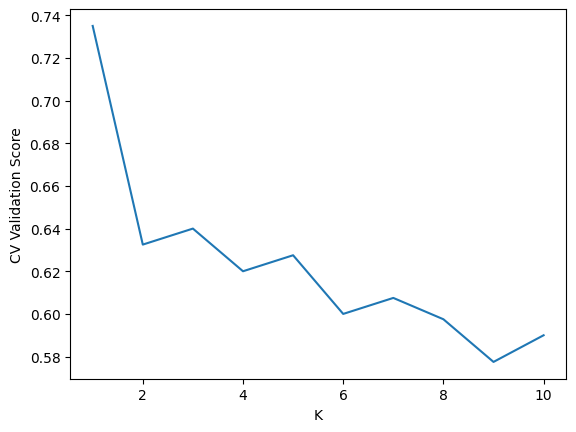

In [36]:
# Looking for the best K in K-nearest neighbour
parameters = {'n_neighbors':[1,2,3,4,5,6,7,8,9,10]}
neighCV = KNeighborsClassifier()
grid = GridSearchCV(neighCV, parameters, cv=5, n_jobs=-1)
grid.fit(dist_average, np.ravel(Yp))

print('The best K is', grid.best_params_.get('n_neighbors'), ' with an average validation score equal to ', grid.best_score_)

# plot the CV validation score for each K value
plt.plot([1,2,3,4,5,6,7,8,9,10], grid.cv_results_.get('mean_test_score'))
plt.xlabel('K')
plt.ylabel('CV Validation Score')



---



We could also use CV to assess the prediction error (generalization error) in a left-out test set.



---



The best K is 1  with an average validation score equal to  0.6639412997903563
The test score is 0.7727272727272727


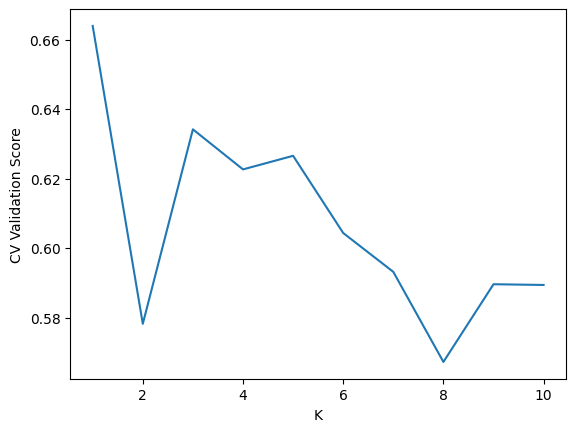

In [37]:
# We only use the training set for finding the best hyper-parameter
parameters = {'n_neighbors':[1,2,3,4,5,6,7,8,9,10]}
neighCV = KNeighborsClassifier()
grid = GridSearchCV(neighCV, parameters, cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

print('The best K is', grid.best_params_.get('n_neighbors'), ' with an average validation score equal to ', grid.best_score_)

# plot the CV validation score for each K value
plt.plot([1,2,3,4,5,6,7,8,9,10], grid.cv_results_.get('mean_test_score'))
plt.xlabel('K')
plt.ylabel('CV Validation Score')

# Let's now use the best model to assess the test score
BestModel=grid.best_estimator_
print('The test score is', BestModel.score(X_test, y_test))



---



**Question**: Comment the results of the two previosu experiments. What about the best K and validation/test error ? Are the results the same ? Why in your opinion ?



---

We get the same result. The best $K$ is equal to 1. Meaning that the best strategy is to classify the image based on the closest one in the training dataset. This is generally prone to overfitting, but here it performes well because of the nature of the features that encapsulate individual-specific pattern. (The closest neighbor is oftern the paired image of the same person with the other expression).



---



It seems that these features do not work very well... let's try to change them.
We can use the distances between all combinations of landmarks. Each subject has M*(M-1)/2 features.



---



In [41]:
# Use distances between all combinations of landmarks. Each subject has M*(M-1)/2 features
dist_combination=np.zeros((N,int((M*(M-1)/2))))
for i in range(N):
    landmark = XpGPA[i].reshape((M, 2))
    idx = 0
    for j in range(M):
        for k in range(j+1, M):
            dist = np.linalg.norm(landmark[j] - landmark[k])
            dist_combination[i, idx] = dist
            idx += 1

print('Number of subjects N is: ', dist_combination.shape[0], ' ; number of features is: ',  dist_combination.shape[1] )


Number of subjects N is:  400  ; number of features is:  2278


In [42]:
X2_train, X2_test, y2_train, y2_test = train_test_split(dist_combination, np.ravel(Yp), test_size=0.33, random_state=42)

**Question**: Should we scale/normalize the new features ?

Use the classification algorithms seen before to test the discriminative power of the new features. 

In [44]:
# Test discriminative power of new features
print("Fitting LDA on new features")
lda_score = cross_val_score(LinearDiscriminantAnalysis(), X=dist_combination, y=np.ravel(Yp), cv=5)
print("LDA CV score: {:.3f} +- {:.3f}".format(lda_score.mean(), lda_score.std()))

print("Fitting KNN on new features")
knn_score = cross_val_score(KNeighborsClassifier(n_neighbors=3), X=dist_combination, y=np.ravel(Yp), cv=5)
print("KNN CV score: {:.3f} +- {:.3f}".format(knn_score.mean(), knn_score.std()))

print("Fitting Logistic Regression on new features")
logit_score = cross_val_score(LogisticRegression(solver='lbfgs'), X=dist_combination, y=np.ravel(Yp), cv=5)
print("Logistic CV score: {:.3f} +- {:.3f}".format(logit_score.mean(), logit_score.std()))

Fitting LDA on new features
LDA CV score: 0.957 +- 0.023
Fitting KNN on new features
KNN CV score: 0.950 +- 0.029
Fitting Logistic Regression on new features
Logistic CV score: 0.950 +- 0.018




---



mmmm it seems that some variables are collinear. Collinearity means that one variable can be linearly predicted by the others, basically it means that there is redundancy. 

**Question**: Which technique could you use to reduce the collinearity/redundancy ? Use it and test the predictive power of the new features.




---
We need to remove some landmarks that is responsible for this, i.e dimension reduction. For that, we can use PCA to reduce the collinearity and redundancy.


In [49]:
# Reduce dimensionality with PCA
from sklearn.decomposition import PCA

# Apply PCA to keep 95% of variance
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(dist_combination)

print("Original features shape:", dist_combination.shape)
print("PCA features shape:", X_pca.shape)
print("Explained variance ratio:", pca.explained_variance_ratio_[:10])  # First 10 components

# Test with LDA
lda_pca_score = cross_val_score(LinearDiscriminantAnalysis(), X=X_pca, y=np.ravel(Yp), cv=5)
print("LDA CV score on PCA features: {:.3f} +- {:.3f}".format(lda_pca_score.mean(), lda_pca_score.std()))

Original features shape: (400, 2278)
PCA features shape: (400, 12)
Explained variance ratio: [0.29227503 0.2145242  0.17743948 0.11779804 0.04162619 0.02892116
 0.02367097 0.0172595  0.01377056 0.01029567]
LDA CV score on PCA features: 0.940 +- 0.040




---


A second solution, would be to manually select few landmarks



---



In [46]:
# Select lateral landmarks mouth
select_land=[49,50,60,55,54,56]
indeces_central=[]
for k in range(0,len(select_land)):
    indeces_central.append(select_land[k]*2-2) # Remember that landmarks are M*2 vectors (odds values are the x and even values are the y)
    indeces_central.append(select_land[k]*2-1)
    
indeces_central=np.array(indeces_central,dtype=int)
Ms=int(len(indeces_central)/2) 
Xps=np.zeros((N,Ms*dim))
XpsGPA=np.zeros((N,Ms*dim))
for i in range(0,N):
    XpsGPA[i,:]=XpGPA[i,indeces_central]
    Xps[i,:]=Xp[i,indeces_central]
    
Yps=Yp
  
print('Number of subjects N is: ', XpsGPA.shape[0], ' ; number of features is: ',  XpsGPA.shape[1] )  

Number of subjects N is:  400  ; number of features is:  12


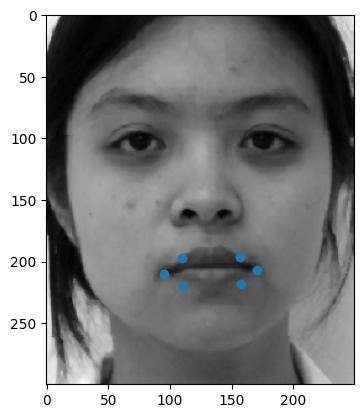

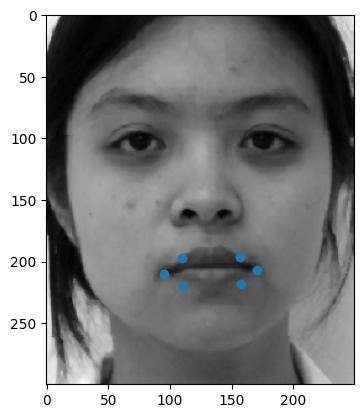

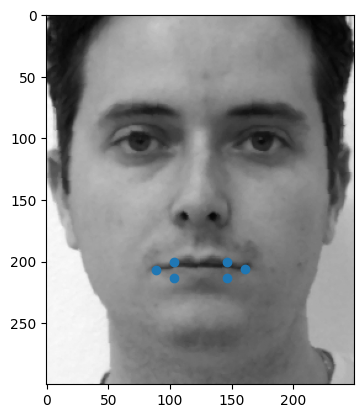

In [47]:
# plot two test images 
for i in range(0,2):
    image = Imagesp[i,:,:]
    plt.figure()
    plt.imshow(image, cmap='gray', origin='upper')
    landmark=Xps[i,:]
    x=landmark[::2]
    y=landmark[1::2]
    plt.plot(x,y,'o')
    plt.show()

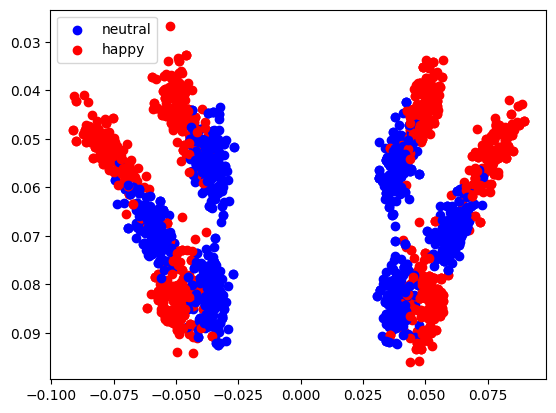

In [48]:
# Plot only selected landmarks
plt.figure()
for i in range(0,N):
    landmark=XpsGPA[i]
    x=landmark[::2]
    y=landmark[1::2]
    if Yps[i].astype(int)==0:
        neutral=plt.scatter(x, y, c='b')
    else:
        happy=plt.scatter(x, y, c='r')
        
plt.legend((neutral,happy),('neutral','happy'))
plt.gca().invert_yaxis()

In [50]:
# Fitting LDA
print("Fitting LDA")
lda = LinearDiscriminantAnalysis()
lda_validate = cross_validate(lda,X=XpsGPA, y=np.ravel(Yps), cv=5, n_jobs=-1, return_train_score=True, return_estimator=True )
print(" Average and std train score : {0} +- {1}".format(lda_validate['train_score'].mean(), lda_validate['train_score'].std() ))
print(" Average and std test score : {0} +- {1}".format(lda_validate['test_score'].mean(), lda_validate['test_score'].std() ))

# Let's look for the best CV model (the one with the best test score)
best_estimator=lda_validate['estimator'][np.argmax(lda_validate['test_score'])]
C=best_estimator.predict(XpsGPA)

# Let's find the images where it did a mistake
error=np.ravel(np.array(np.where(np.abs(C-np.ravel(Yps)))))  
if len(error)>5:
    kk=5
else:
    kk=len(error)

Fitting LDA
 Average and std train score : 0.95875 +- 0.004145780987944228
 Average and std test score : 0.9425000000000001 +- 0.020310096011589895


---

Let's plot some images where the best model was wrong. 

---

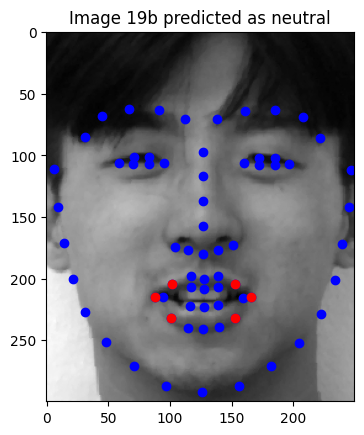

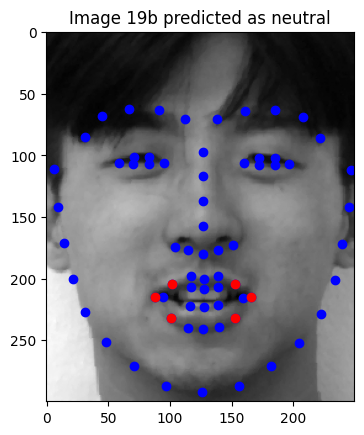

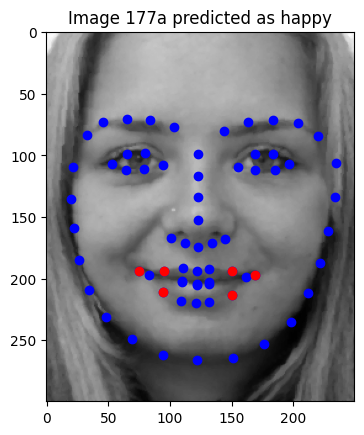

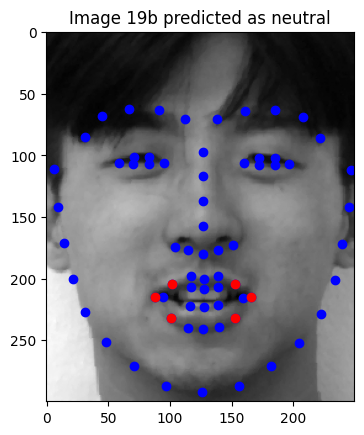

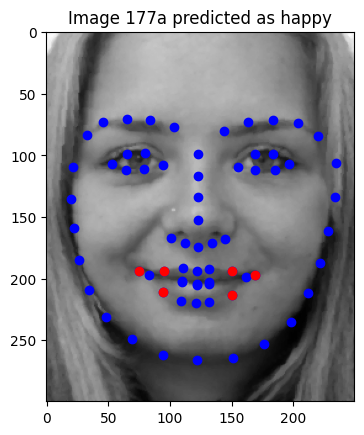

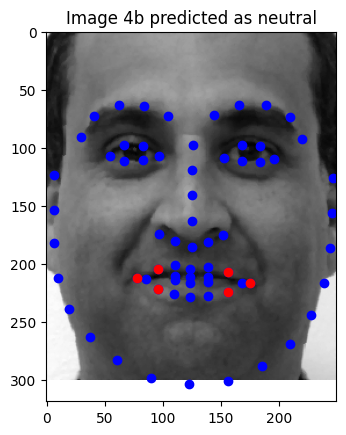

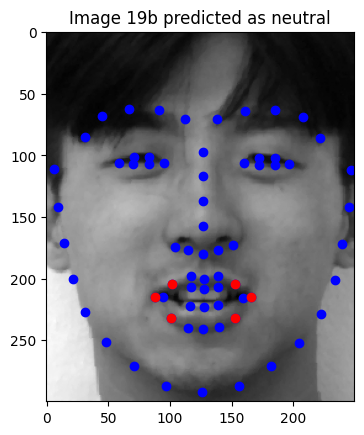

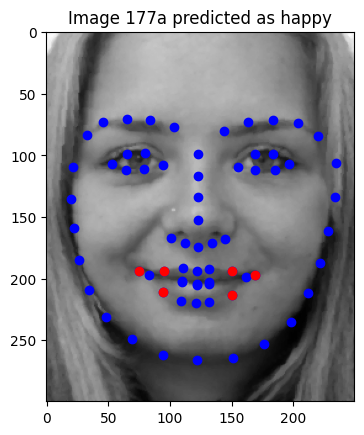

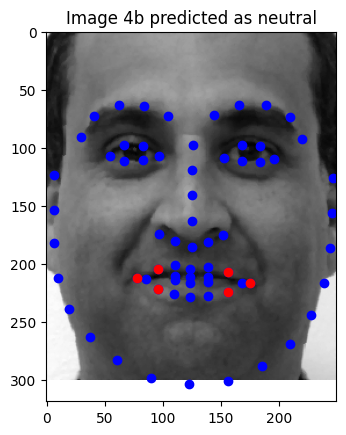

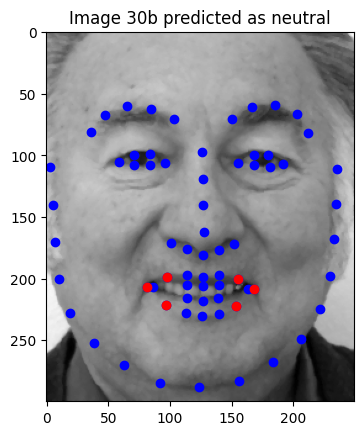

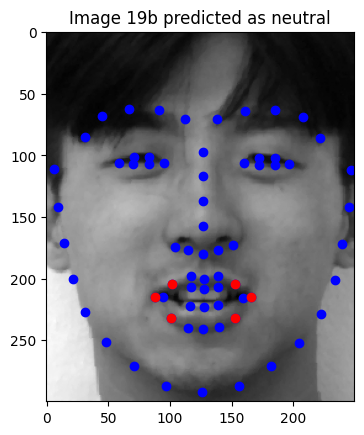

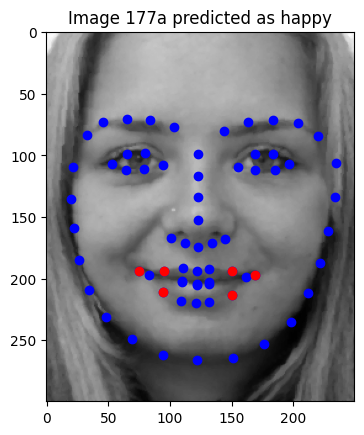

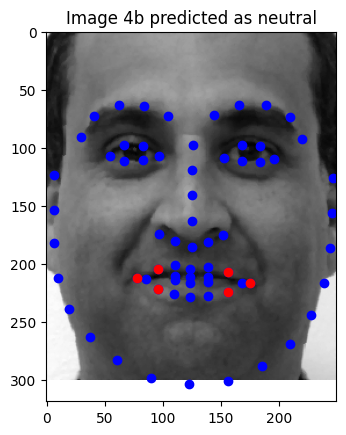

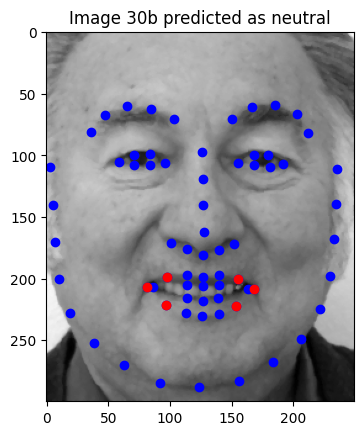

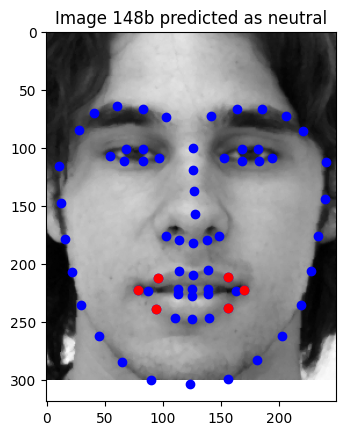

In [51]:
# plot error images
for i in range(0,kk):
    image = Imagesp[error[i],:,:]
    plt.figure()
    plt.imshow(image, cmap='gray', origin='upper')
    landmarkALL=Xp[error[i],:]
    landmark=Xps[error[i],:]
    xALL=landmarkALL[::2]
    yALL=landmarkALL[1::2]
    x=landmark[::2]
    y=landmark[1::2]
    plt.plot(xALL,yALL,'ob')
    plt.plot(x,y,'or')
    if  C[error[i]]==0:
        plt.title('Image ' + Namesp[error[i]] + ' predicted as neutral')
    elif C[error[i]]==1:
        plt.title('Image ' + Namesp[error[i]] + ' predicted as happy')
    plt.show()
 

**Question**: Comment the results. Why did the algorithm make a mistake ? Would you choose other landmarks ? Try at least another combination of landmarks


In [58]:
# Try another combination of landmarks: select eyebrows landmarks
select_land_eyes = [18, 19, 20, 21, 22, 23, 24, 25, 26, 27]  # Eyebrows landmarks
indeces_eyes = []
for k in range(0, len(select_land_eyes)):
    indeces_eyes.append(select_land_eyes[k]*2-2)
    indeces_eyes.append(select_land_eyes[k]*2-1)

indeces_eyes = np.array(indeces_eyes, dtype=int)
Ms_eyes = int(len(indeces_eyes)/2)
Xps_eyes = np.zeros((N, Ms_eyes*dim))
XpsGPA_eyes = np.zeros((N, Ms_eyes*dim))
for i in range(0, N):
    XpsGPA_eyes[i, :] = XpGPA[i, indeces_eyes]
    Xps_eyes[i, :] = Xp[i, indeces_eyes]

Yps_eyes = Yp

# Test with LDA
lda_eyes_score = cross_val_score(LinearDiscriminantAnalysis(), X=XpsGPA_eyes, y=np.ravel(Yps_eyes), cv=5)
print("LDA CV score on eye landmarks: {:.3f} +- {:.3f}".format(lda_eyes_score.mean(), lda_eyes_score.std()))

LDA CV score on eye landmarks: 0.728 +- 0.053


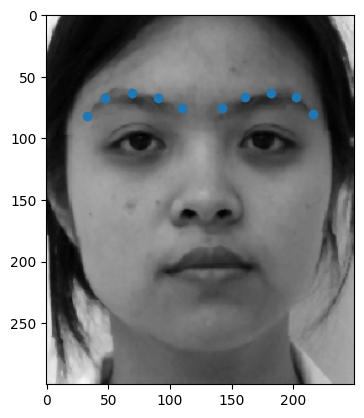

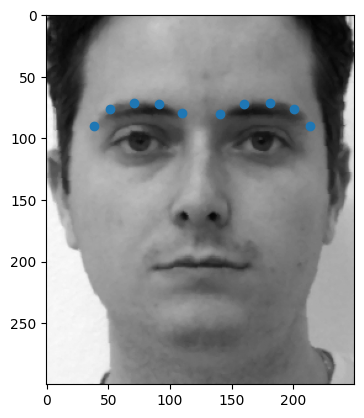

In [62]:
# plot two test images 
for i in range(0,2):
    image = Imagesp[i,:,:]
    plt.figure()
    plt.imshow(image, cmap='gray', origin='upper')
    landmark=Xps_eyes[i,:]
    x=landmark[::2]
    y=landmark[1::2]
    plt.plot(x,y,'o')
    plt.show()




---


Here, we use Nested Cross-Validation for finding the generalization error and the best K value



---



In [53]:
# Fitting K-nearest neighbour with Nested Cross-Validation
 
print("Fitting K-nearest neighbour with Nested CV")
t0 = time()
neigh = KNeighborsClassifier()
parameters = {'n_neighbors':[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]}
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=666) # we fix the random state to always have the same results if we relaunch the code
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=666)
# Nested CV with parameter optimization
clf = GridSearchCV(estimator=neigh, param_grid=parameters, cv=inner_cv)
nested_CV = cross_validate(estimator=clf, X=XpsGPA, y=np.ravel(Yps), cv=outer_cv,return_train_score=True, return_estimator=True, n_jobs=-1)
print("done in %0.3fs" % (time() - t0))
print("Average and std Nested Cv train score : {0} +- {1}".format(nested_CV['train_score'].mean(), nested_CV['train_score'].std() ))
print("Average and std Nested Cv test score : {0} +- {1}".format(nested_CV['test_score'].mean(), nested_CV['test_score'].std() ))

Fitting K-nearest neighbour with Nested CV
done in 1.649s
Average and std Nested Cv train score : 1.0 +- 0.0
Average and std Nested Cv test score : 0.9625 +- 0.011180339887498959


---

**Question**: Are Training and Test scores similar ? What does it mean ?

---

It is almost similar. The model overfits but correctly predicts almost all of the dataset. This means that the datas are too similar to each others.

**Question (OPTIONAL)**: Please propose at least another set of features using landmarks and/or pixel intensities of the images and test its discriminative power